# Active-SLAM experiment visualisation

Compare saved eQMARL, qfCTDE, fCTDE, and sCTDE runs, then inspect a two-robot frontier-policy rollout. Run training first so `experiment_output/active_slam_maa2c_*/` contains metric files.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, display

from eqmarl.active_slam_visualization import (
    animate_rollout, discover_metric_files, load_metrics, plot_learning_curves,
    plot_slam_frame, rollout, summarize_final_metrics,
)
from eqmarl.environments.active_slam import MultiAgentSLAMEnv
from eqmarl.policies import FrontierJointPolicy

/home/youngei402tw/miniconda3/envs/eQMARL_SLAM/lib/python3.9/site-packages/google/api_core/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
2026-07-28 15:29:37.616033: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:925] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-28 15:29:37.946302: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:925] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-28 15:29:37.946409: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:925] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:

In [2]:
groups = discover_metric_files(Path.cwd().parent / 'experiment_output')
if not groups:
    groups = discover_metric_files('experiment_output')
groups

{'eqmarl_psi+': [PosixPath('/home/youngei402tw/projects/eqmarl/experiment_output/active_slam_maa2c_eqmarl_psi+/20260728T142326/metrics-0.json')],
 'fctde': [PosixPath('/home/youngei402tw/projects/eqmarl/experiment_output/active_slam_maa2c_fctde/20260728T142458/metrics-0.json')],
 'qfctde': [PosixPath('/home/youngei402tw/projects/eqmarl/experiment_output/active_slam_maa2c_qfctde/20260728T142425/metrics-0.json')],
 'sctde': [PosixPath('/home/youngei402tw/projects/eqmarl/experiment_output/active_slam_maa2c_sctde/20260728T142529/metrics-0.json')]}

In [ ]:
data = load_metrics(groups)
data.head()

,framework,run,episode,team_reward,coverage,occupancy_iou,pose_rmse,collisions,path_length,redundant_coverage,pose_uncertainty,success
0,eqmarl_psi+,0,0,1.617292,0.277136,0.607143,0.339183,0.0,2.0,0.0,0.343173,0.0
1,fctde,0,0,1.512346,0.263279,0.547170,0.373523,0.0,2.0,0.0,0.339449,0.0
2,qfctde,0,0,1.617292,0.277136,0.607143,0.339183,0.0,2.0,0.0,0.343173,0.0
3,sctde,0,0,1.512346,0.263279,0.547170,0.373523,0.0,2.0,0.0,0.339449,0.0


: 

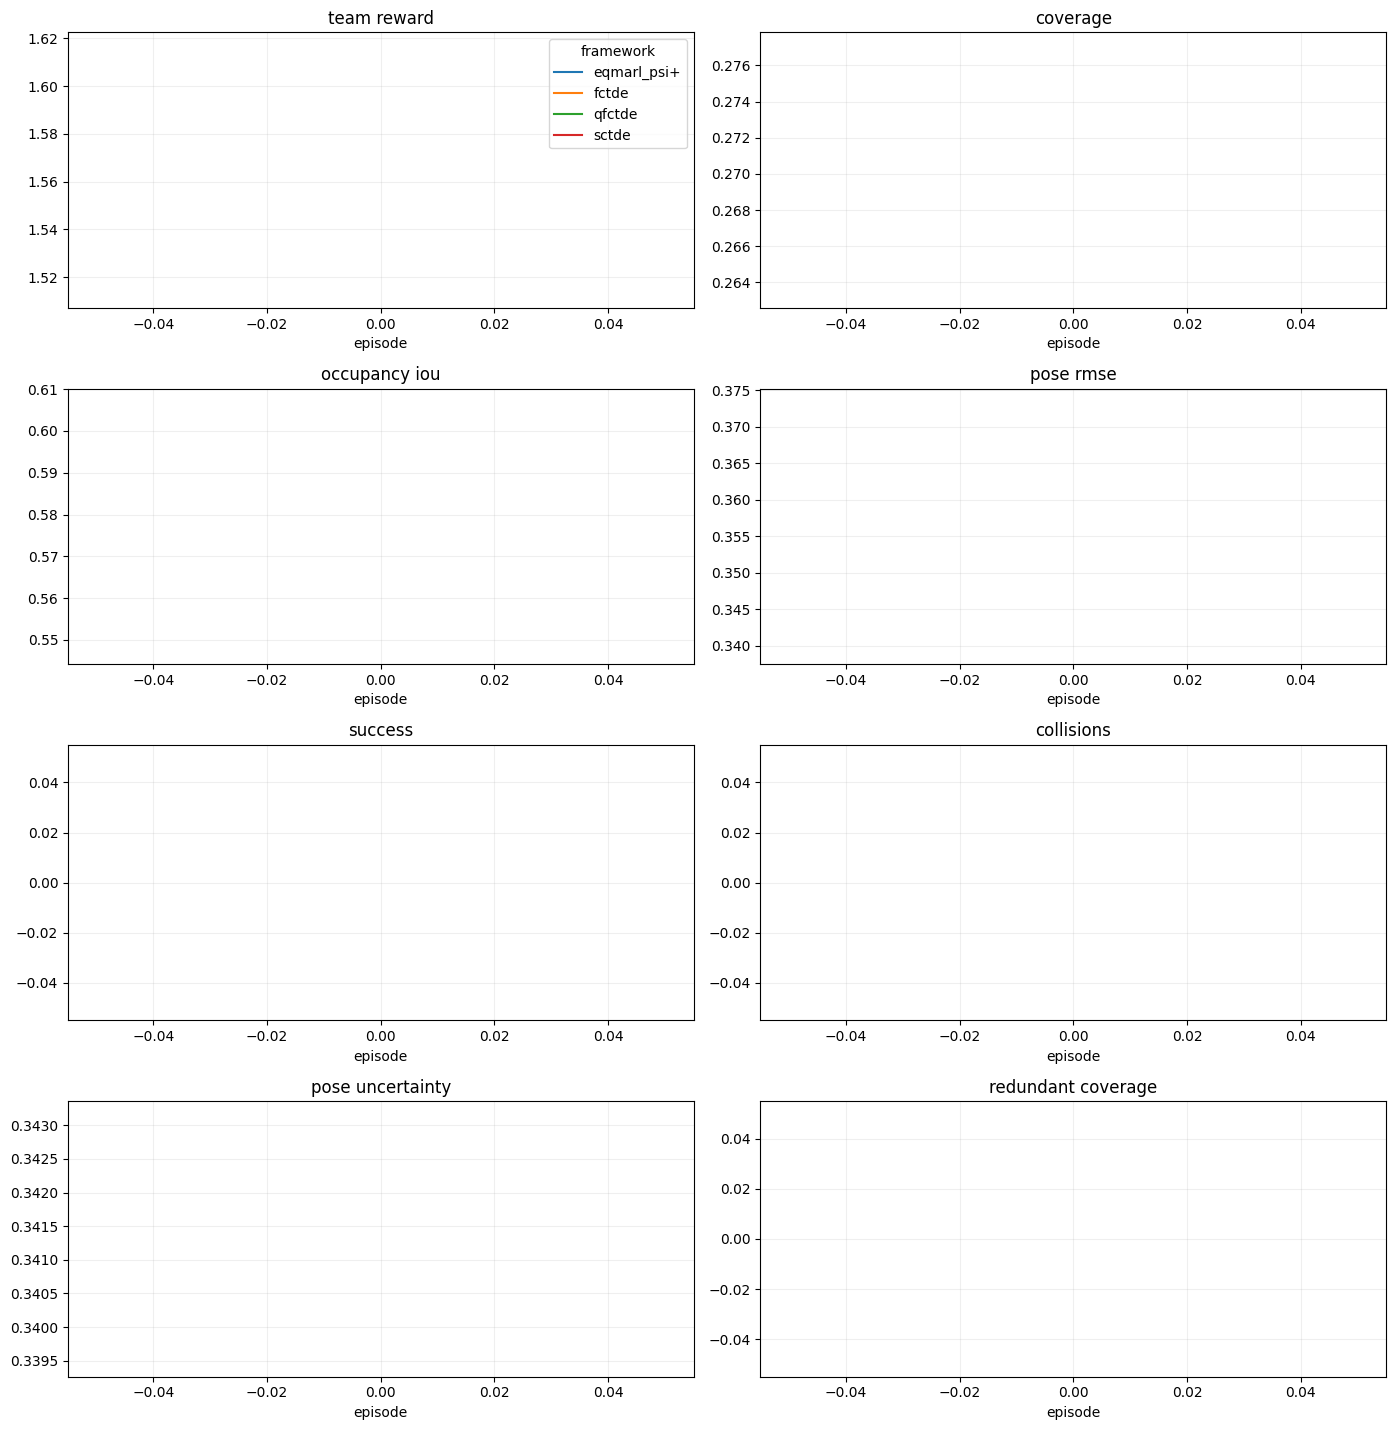

In [4]:
figure = plot_learning_curves(data, smoothing=50)
plt.show()

The table reports the mean final-window score per seed and its 95% confidence interval. `team_reward` is the learning objective; coverage, occupancy IoU, and pose RMSE measure the SLAM result directly.

In [5]:
summary = summarize_final_metrics(data, window=100)
summary.pivot(index='framework', columns='metric', values=['mean', 'ci95']).round(3)

mean                                                    \
metric      collisions coverage occupancy_iou pose_rmse pose_uncertainty   
framework                                                                  
eqmarl_psi+        0.0    0.277         0.607     0.339            0.343   
fctde              0.0    0.263         0.547     0.374            0.339   
qfctde             0.0    0.277         0.607     0.339            0.343   
sctde              0.0    0.263         0.547     0.374            0.339   

                                                         ci95           \
metric      redundant_coverage success team_reward collisions coverage   
framework                                                                
eqmarl_psi+                0.0     0.0       1.617        0.0      0.0   
fctde                      0.0     0.0       1.512        0.0      0.0   
qfctde                     0.0     0.0       1.617        0.0      0.0   
sctde                      0.0     0.0       1.512        0.0      0.0   

                                                                         \
metric      occupancy_iou pose_rmse pose_uncertainty redundant_coverage   
framework                                                                 
eqmarl_psi+           0.0       0.0              0.0                0.0   
fctde                 0.0       0.0              0.0                0.0   
qfctde                0.0       0.0              0.0                0.0   
sctde                 0.0       0.0              0.0                0.0   

                                 
metric      success team_reward  
framework                        
eqmarl_psi+     0.0         0.0  
fctde           0.0         0.0  
qfctde          0.0         0.0  
sctde           0.0         0.0

## Rollout inspection

This uses the deterministic frontier baseline, so the notebook remains usable before learned checkpoints are available. The left panel is the ground truth; the right panel is the conventional SLAM backend's fused occupancy belief.

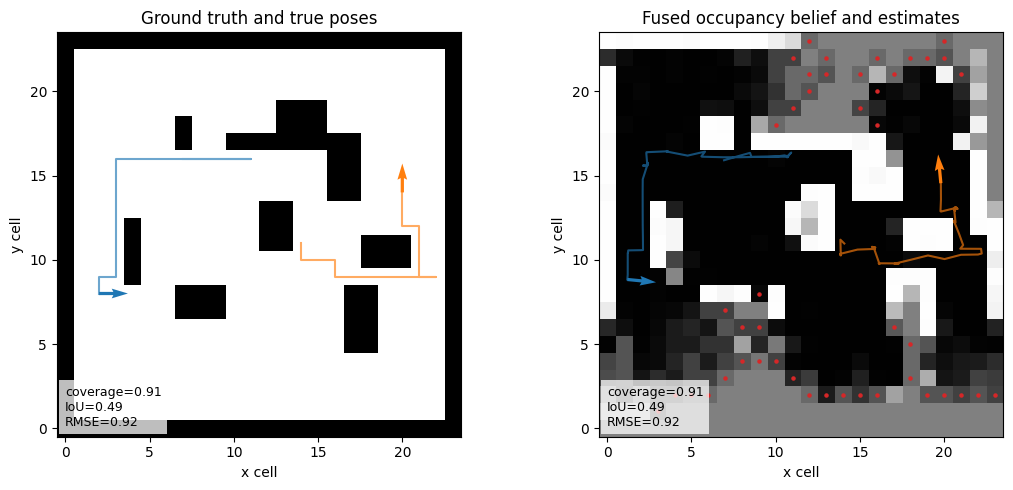

In [6]:
env = MultiAgentSLAMEnv(map_size=24, time_limit=80)
frames = rollout(env, FrontierJointPolicy(), seed=7)
figure = plot_slam_frame(frames[-1], history=frames)
plt.show()

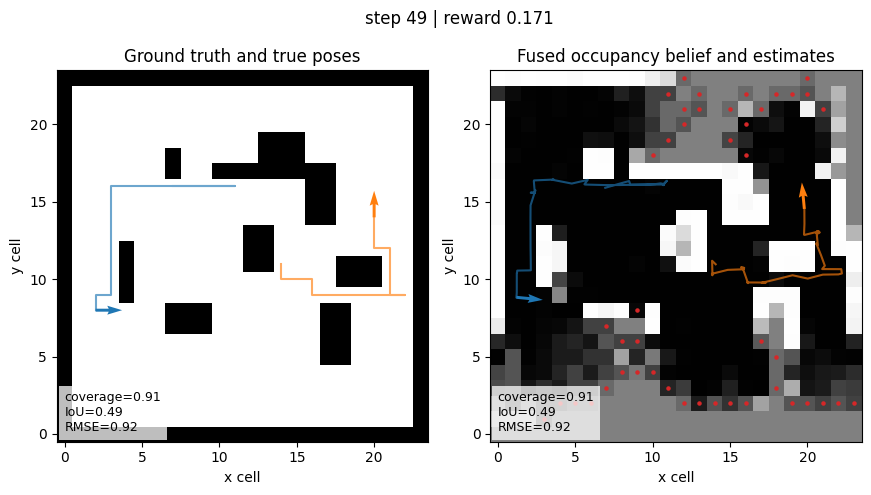

In [7]:
display(HTML(animate_rollout(frames, interval=220).to_jshtml()))